In [1]:
#  PuLP package - a simple python based package that allows us to formulate and solve linear (and integer) programs.

#install pulp if not already there

try:
    %load_ext pulp
except:
    !pip install pulp
    

The pulp module is not an IPython extension.


In [20]:
from pulp import *

# pulp wiki - https://www.coin-or.org/PuLP/pulp.html
# Step 1: Creating a problem data-structure. The 'name' provided is simply a descriptive name whereas the second argument specifies whether we seek to minimize or maximize an objective function.

problem = LpProblem('name', LpMinimize) # Use LpMaximize if you are maximizing an objective function

# Step 2: Create decision variables

x_1 = LpVariable('x_1')
x_2 = LpVariable('x_2', 0) # lower bounds 0. In other words,
x_3 = LpVariable('x_3', 0)
x_4 = LpVariable('x_4', 0)
x_5 = LpVariable('x_5', -1, 1) # x_5 with lower bound -1 and upper bound +1. In other words, constraints x_5 >= -1, x_5 <= 1


# We would like our objective function to be x_1 + x_2 - x_3 + 2 * x_4 - 3 * x_5. Note that we already specified that we are minimizing it when we created the problem.

problem += (x_1 + x_2 - x_3 + 2*x_4 - 3 * x_5)


# We would like to add three constraints - Constraint # 1: x_1 - 2 * x_2 + x_3 <= 5 Constraint # 2: 2 x_2 - x_4 + x_5 <= 7 Constraint # 3: x_1 - x_5 + 2 * x_4 <= 8
problem += (x_1 - 2 * x_2 + x_3 <= 5)
problem += (2* x_2 - x_4 + x_5  <= 7)
problem += (x_1 - x_5 + 2 * x_4 <= 8)


# Solve the problem and extract the solution.
problem.solve() # -2 / linear relaxation unbounded

print('Status is :', LpStatus[problem.status])

if problem.status == constants.LpStatusOptimal:
    print('Optimal Solution Found!!')
    # Extract the values of the decision variables.
    v_1 = x_1.varValue
    v_2 = x_2.varValue
    v_3 = x_3.varValue
    v_4 = x_4.varValue
    v_5 = x_5.varValue
    print('x_1 = {v_1}, x_2 = {v_2}, x_3 = {v_3}, x_4 = {v_4}, x_5={v_5}')
elif problem.status == constants.LpStatusUnbounded:
    print('Unbounded solution -- need more constraints')
elif problem.status == constants.LpStatusInfeasible:
    print('Problem has no feasible solution')
else: 
    print('Problem has an undefined status -- something went wrong.')

# Ooops: our problem is unbounded. We need more constraints to make it bounded. Let's add constraints - x_1 >= -5 and x_3 <= 15

problem2 = LpProblem('name', LpMinimize) # Use LpMaximize if you are maximizing an objective function
x_1 = LpVariable('x_1')
x_2 = LpVariable('x_2', 0)
x_3 = LpVariable('x_3', 0)
x_4 = LpVariable('x_4', 0)
x_5 = LpVariable('x_5', -1, 1)
problem2 += (x_1 + x_2 - x_3 + 2*x_4 - 3 * x_5)
problem2 += (x_1 - 2 * x_2 + x_3 <= 5)
problem2 += (2* x_2 - x_4 + x_5  <= 7)
problem2 += (x_1 - x_5 + 2 * x_4 <= 8)
problem2 += x_1 >= -5
problem2 += x_3 <= 15

# Let's make a nice function to solve our problem and extract the solution as a list.

def solve_and_extract_solution(problem, list_of_vars):
    ## Solve and check status again
    problem.solve() # solve the problem
    print('Status is :', LpStatus[problem.status])
    if problem.status == constants.LpStatusOptimal:
        print('Optimal Solution Found!!')
        sols = [x.varValue for x in list_of_vars]
        ## Alternatively you could write a for loop 
        ## sols = []
        ## for x in list_of_vars:
        ##    sols.append(x.varValue)
        print('Solution:',sols)
        print('Objective Value:', problem.objective.value())
        return sols
    elif problem.status == constants.LpStatusUnbounded:
        print('Unbounded solution -- need more constraints')
        return None
    elif problem.status == constants.LpStatusInfeasible:
        print('Problem has no feasible solution')
        return None
    else: 
        print('Problem has an undefined status -- something went wrong.')
        return None
print("---------problem 2----------")
solve_and_extract_solution(problem2, [x_1, x_2, x_3, x_4, x_5])

print("---------problem 3----------")
problem3 = LpProblem('my_problem', LpMaximize)
x = LpVariable('x', lowBound = 0)
y = LpVariable('y', lowBound = 0, upBound = 4)
problem3 += (x + 2 * y) 
problem3 += (x <= y + 3)
problem3 += (x >= y - 1 )
problem3 += (x - 2 * y <= 5)
print(y.value())
status = problem3.solve()
assert status == LpStatusOptimal
print(x.value())
print(y.value())
print(problem3.objective.value())

print("----------problem 4 -------------")
problem4 = LpProblem('n_problem', LpMaximize)
n = 15
vars = [ LpVariable(f'x{i}', lowBound = 0.0) for i in range(n)]
problem4 += lpSum(vars)
for i in range(14):
    problem4 += vars[i] - vars[i+1] <= i 
    problem4 += vars[i] - vars[i+1] >= -i
status = problem4.solve() 
if status == LpStatusOptimal:
    print('Optimal solution found!')
    print([vi.value() for vi in vars])
    print(problem4.objective.value())
elif status == LpStatusInfeasible:
    print('Infeasible problem')
elif status == LpStatusUnbounded:
    print('Unbounded problem')
else:
    print('Unknown status')


Status is : Unbounded
Unbounded solution -- need more constraints
---------problem 2----------
Status is : Optimal
Optimal Solution Found!!
Solution: [-5.0, 2.5, 15.0, 0.0, 1.0]
Objective Value: -20.5
---------problem 3----------
None
7.0
4.0
15.0
----------problem 4 -------------
Unbounded problem




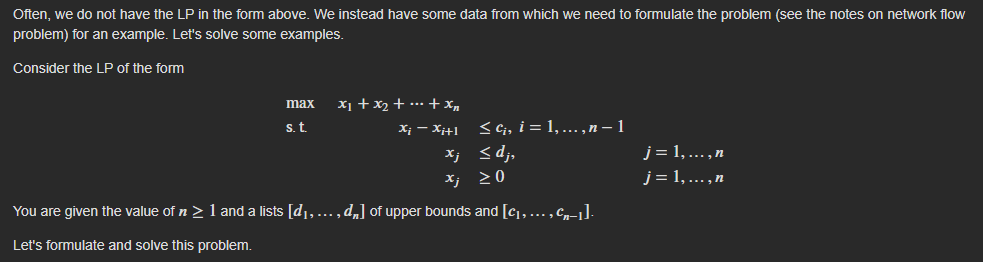


In [11]:
def formulate_and_solve(c_list, d_list):
    n = len(d_list)
    assert len(c_list) == n-1
    prob = LpProblem('special_problem', LpMaximize) # set it to maximize the objective
    # 1. Create Decision Variables
    ## option 1
    ## list_of_vars = []
    ## for i in range(n):
    ##     new_var = LpVariable(f'x_{i+1}', 0, d_list[i]) # create a variable named x_{i} with lower bound 0 
    ##     list_of_vars.append(new_var)
    ## more elegant one liner in python
    list_of_vars = [LpVariable(f'x_{j+1}', 0, d_list[j]) for j in range(n) ]
    # Note that the constraints x_j >= 0 and x_j <= d_j are taken care of already.
    print(f'Created list of variables: {list_of_vars}')
    # 2. Set the objective
    ## option 1
    ## e = 0
    ## for x in list_of_vars:
    ##     e = e + x
    ## prob += e
    ## More elegant option 2
    prob += lpSum(list_of_vars) ## sum up all the elements in list to create an expression
    # 3. Add constraints
    for i in range(n-1):
        prob += list_of_vars[i] - list_of_vars[i+1] <= c_list[i] # x_i - x_{i+1} <= c_i
    
    # 4. Solve and extract solution
    sol_list = solve_and_extract_solution(prob, list_of_vars)
    return sol_list 

In [12]:
formulate_and_solve([1, 4, 6, 8, 0], [5, 1, 2, 3, 2, 6])

Created list of variables: [x_1, x_2, x_3, x_4, x_5, x_6]
Status is : Optimal
Optimal Solution Found!!
Solution: [2.0, 1.0, 2.0, 3.0, 2.0, 6.0]
Objective Value: 16.0


[2.0, 1.0, 2.0, 3.0, 2.0, 6.0]